In [13]:
import pandas as pd
import numpy as np

In [14]:
#Clean data

#Read excel file into a dataframe
df = pd.read_excel('DNNL_database.xlsx')

#Drop Nan values
df = df.dropna(subset=['First Name'])

#Remove names that have numbers
remove_numbers = df['First Name'].astype(str).str.contains(r'\d')
df = df[~remove_numbers]

#Clean names that have punctuation or spaces
df['First Name'] = df['First Name'].astype(str).str.split('.').str[0]
df['First Name'] = df['First Name'].astype(str).str.split().str[0]

#Select and keep only the values that are longer than 3 to make sure they are actually names
check_length = df['First Name'].astype(str).apply(len) >= 3
df = df[check_length]


display(df)

,Record ID,First Name,Last Name,Became a Lead Date,City,Company Name,Create Date,Email Domain,IP City,Last Activity Date,Last Contacted,Associated Company
7,45451,edvanengel,NaN,2023-11-28 13:54:00,NaN,NaN,2023-11-28 13:54:00,gmail.com,NaN,2023-11-29 11:06:00,2023-11-29 11:06:00,NaN
8,45401,erica,NaN,2023-11-28 13:54:00,NaN,NaN,2023-11-28 13:54:00,beliefinbusiness.com,NaN,2023-11-28 13:00:00,2023-11-28 13:00:00,Erica van Engel
12,45201,joris,NaN,2023-11-27 15:02:00,NaN,NaN,2023-11-27 15:02:00,luissbusinessschool.nl,NaN,2023-11-27 14:58:00,2023-11-27 14:58:00,Luissbusinessschool
17,45104,Marlene,ten Ham,2023-11-24 15:54:00,NaN,NaN,2023-11-24 15:54:00,thuiswinkel.org,NaN,2023-11-24 22:07:00,2023-11-24 15:54:00,Thuiswinkel.org
21,45051,jamila,NaN,2023-11-22 11:36:00,NaN,NaN,2023-11-22 11:36:00,surmotion.nl,NaN,2023-11-22 11:00:00,2023-11-22 11:00:00,Surmotion.nl
...,...,...,...,...,...,...,...,...,...,...,...,...
1321,1123,Stephany,NaN,2021-11-26 21:09:00,NaN,NaN,2021-11-26 20:18:00,going-social.nl,NaN,NaT,NaT,going-social.nl
1322,1114,Saundra,NaN,2022-12-28 12:12:00,NaN,NaN,2021-11-26 20:18:00,gmail.com,NaN,NaT,NaT,NaN
1323,1106,Siri,Boe-Lillegraven,NaT,NaN,NaN,2021-11-26 20:18:00,uva.nl,NaN,NaT,NaT,University of Amsterdam
1325,1131,Tino,NaN,2022-07-11 17:50:00,NaN,NaN,2021-11-26 20:18:00,gmail.com,tervuren,NaT,NaT,NaN


In [4]:
# import genderize api to assess gender 
import requests
import json

def identify_gender(first_name):
    base= 'https://api.genderize.io?'

    url= f'{base}name={first_name}'
    result=requests.get(url)
    
    json_str = result.text
    details= json.loads(json_str)
    return details
# Test
res= identify_gender("Sasha")
print(res)

{'count': 14512, 'name': 'Sasha', 'gender': 'female', 'probability': 0.52}


In [5]:
#Separate data in batches because the genderize API has a limit of 100 per day

names= [x for x in df['First Name']]

#Select 99 values because we used one to initialize the function
values = 99

batches = [names[i:i+values] for i in range(0, len(names), values)]

#Add all batches in a nested list for easy access when calling the function
n_list=[]
for i, batch in enumerate(batches, start=1):
    nested_list.append(batch)

print(len(nested_list))

In [9]:
#BATCH 1

import csv

#Import genderize function
gender_1= [identify_gender(x)for x in n_list[0]]
estimated_gender_1= [x['gender'] for x in gender_1]

csv_path = 'name_lists.csv'

# Write the list to the CSV file
with open(csv_path, 'w', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_1)

In [13]:
csv_path = 'name_lists.csv'
with open(csv_path, 'r') as csvfile:
    data_list = list(csv.reader(csvfile))

print(data_list)

[['', 'female', 'male', 'female', 'female', 'male', 'male', 'female', 'male', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'male', 'male', 'female', 'male', '', 'female', 'female', 'female', '', 'female', 'male', 'male', 'male', 'male', 'female', 'male', 'female', 'female', '', 'male', 'female', '', 'male', 'female', 'male', 'female', 'male', '', 'female', 'male', 'female', '', 'male', 'male', 'male', 'male', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'female', 'female', 'male', 'male', '', 'male', 'male', 'female', 'male', 'female', 'female', 'female', 'male', '', 'male', 'female', '', 'male', 'female', 'female', 'female', 'male', 'female', 'female', 'male', 'female', 'male', 'female', 'female', 'male', 'male', 'male', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'female']]


In [14]:
#BATCH 2

gender_2= [identify_gender(x)for x in n_list[1]]
estimated_gender_2= [x['gender'] for x in gender_2]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_2)

In [15]:
#BATCH 3

gender_3= [identify_gender(x)for x in n_list[2]]
estimated_gender_3= [x['gender'] for x in gender_3]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_3)

In [19]:
#BATCH 4

gender_4= [identify_gender(x)for x in n_list[3]]
estimated_gender_4= [x['gender'] for x in gender_4]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_4)

In [20]:
#BATCH 5

gender_5= [identify_gender(x)for x in n_list[4]]
estimated_gender_5= [x['gender'] for x in gender_5]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_5)

In [23]:
#BATCH 6

gender_6= [identify_gender(x)for x in n_list[5]]
estimated_gender_6= [x['gender'] for x in gender_6]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_6)

In [24]:
#BATCH 7

gender_7= [identify_gender(x)for x in n_list[6]]
estimated_gender_7= [x['gender'] for x in gender_7]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_7)

In [25]:
#BATCH 8

gender_8= [identify_gender(x)for x in n_list[7]]
estimated_gender_8= [x['gender'] for x in gender_8]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_8)

In [29]:
#BATCH 9

gender_9= [identify_gender(x)for x in n_list[8]]
estimated_gender_9= [x['gender'] for x in gender_9]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_9)

In [30]:
#BATCH 10

gender_10= [identify_gender(x)for x in n_list[9]]
estimated_gender_10= [x['gender'] for x in gender_10]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_10)

In [32]:
#BATCH 11

gender_11= [identify_gender(x)for x in n_list[10]]
estimated_gender_11= [x['gender'] for x in gender_11]

csv_path = 'name_lists.csv'
with open(csv_path, 'a', newline='') as csvfile:
    csv.writer(csvfile).writerow(estimated_gender_11)

In [15]:
#Import csv and add all values into one list

import csv
csv_path = 'name_lists.csv'
gender_list=[]

with open(csv_path, 'r') as csvfile:
    csv_reader = csv.reader(csvfile)
    
    for row in csv_reader:
        gender_list.extend(row)

#Replace empty strings for names that do not have a gender to undefined
    for x in range(len(gender_list)):
        if gender_list[x] == '':
            gender_list[x] = 'undefined'

print(gender_list)

['undefined', 'female', 'male', 'female', 'female', 'male', 'male', 'female', 'male', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'male', 'male', 'female', 'male', 'undefined', 'female', 'female', 'female', 'undefined', 'female', 'male', 'male', 'male', 'male', 'female', 'male', 'female', 'female', 'undefined', 'male', 'female', 'undefined', 'male', 'female', 'male', 'female', 'male', 'undefined', 'female', 'male', 'female', 'undefined', 'male', 'male', 'male', 'male', 'female', 'female', 'male', 'female', 'male', 'male', 'female', 'female', 'female', 'male', 'male', 'undefined', 'male', 'male', 'female', 'male', 'female', 'female', 'female', 'male', 'undefined', 'male', 'female', 'undefined', 'male', 'female', 'female', 'female', 'male', 'female', 'female', 'male', 'female', 'male', 'female', 'female', 'male', 'male', 'male', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'female', 'male', 'male', 'male', 'undefined'

In [16]:
#Add gender of entrepreneurs to dataframe
df['Entrepreneur Gender'] = gender_list
display(df)

,Record ID,First Name,Last Name,Became a Lead Date,City,Company Name,Create Date,Email Domain,IP City,Last Activity Date,Last Contacted,Associated Company,Entrepreneur Gender
7,45451,edvanengel,NaN,2023-11-28 13:54:00,NaN,NaN,2023-11-28 13:54:00,gmail.com,NaN,2023-11-29 11:06:00,2023-11-29 11:06:00,NaN,undefined
8,45401,erica,NaN,2023-11-28 13:54:00,NaN,NaN,2023-11-28 13:54:00,beliefinbusiness.com,NaN,2023-11-28 13:00:00,2023-11-28 13:00:00,Erica van Engel,female
12,45201,joris,NaN,2023-11-27 15:02:00,NaN,NaN,2023-11-27 15:02:00,luissbusinessschool.nl,NaN,2023-11-27 14:58:00,2023-11-27 14:58:00,Luissbusinessschool,male
17,45104,Marlene,ten Ham,2023-11-24 15:54:00,NaN,NaN,2023-11-24 15:54:00,thuiswinkel.org,NaN,2023-11-24 22:07:00,2023-11-24 15:54:00,Thuiswinkel.org,female
21,45051,jamila,NaN,2023-11-22 11:36:00,NaN,NaN,2023-11-22 11:36:00,surmotion.nl,NaN,2023-11-22 11:00:00,2023-11-22 11:00:00,Surmotion.nl,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1321,1123,Stephany,NaN,2021-11-26 21:09:00,NaN,NaN,2021-11-26 20:18:00,going-social.nl,NaN,NaT,NaT,going-social.nl,female
1322,1114,Saundra,NaN,2022-12-28 12:12:00,NaN,NaN,2021-11-26 20:18:00,gmail.com,NaN,NaT,NaT,NaN,female
1323,1106,Siri,Boe-Lillegraven,NaT,NaN,NaN,2021-11-26 20:18:00,uva.nl,NaN,NaT,NaT,University of Amsterdam,female
1325,1131,Tino,NaN,2022-07-11 17:50:00,NaN,NaN,2021-11-26 20:18:00,gmail.com,tervuren,NaT,NaT,NaN,male


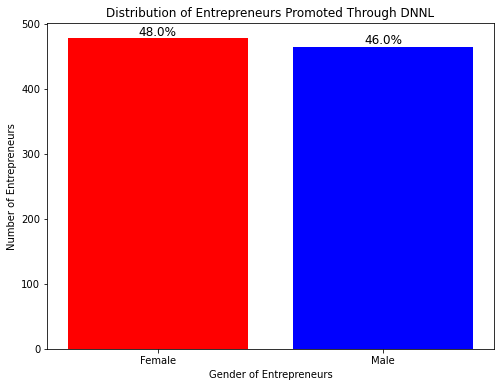

In [20]:
#Plot the gender distribution of entrepreneurs DNNL

import pandas as pd
import matplotlib.pyplot as plt

#Select gender column 
genders=df['Entrepreneur Gender']

#Get value total
total= len(df)

#Count number of female entrepreneurs
female_nr=df.value_counts(subset=genders)['female']
#Divide number of females by total and round percentage
fraction= ((female_nr)/(total))*100
f_p= round(fraction)


#Count number of male entrepreneurs and get percentage
male_nr=df.value_counts(subset=genders)['male']
fraction= ((male_nr)/(total))*100
m_p= round(fraction)



#Plot gender distributions in DNNL
females = df[df['Entrepreneur Gender']=='female'].shape[0]
males = df[df['Entrepreneur Gender']=='male'].shape[0]

plt.figure(figsize=(8, 6))
bar= plt.bar(['Female', 'Male'], [females, males], color=['red', 'blue'])
plt.xlabel('Gender of Entrepreneurs')
plt.ylabel('Number of Entrepreneurs')
plt.title('Distribution of Entrepreneurs Promoted Through DNNL')
#Add percentages above bars
plt.bar_label(bar, labels=[f'{f_p:.1f}%', f'{m_p:.1f}%'], fontsize=12, label_type='edge')

plt.show()

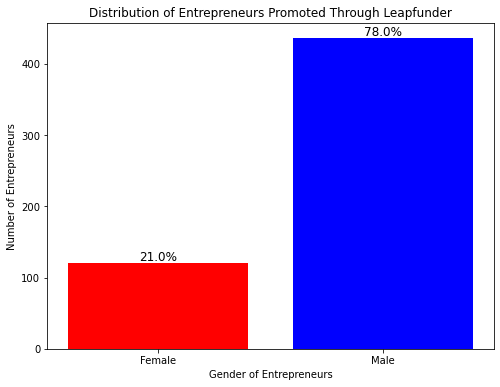

In [24]:
#Plot the gender distribution of entrepreneurs Leapfunder

import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

leapfunder = pd.read_csv('gender_data_leapfunder.csv')

#Select gender column
genders=leapfunder['Gender']

#Get value total
total= len(leapfunder)

#Count number of female entrepreneurs and get percentage
female_nr=leapfunder.value_counts(subset=genders)['female']
fraction= ((female_nr)/(total))*100
f_p= round(fraction)


#Count number of male entrepreneurs and get percentage
male_nr=leapfunder.value_counts(subset=genders)['male']
fraction= ((male_nr)/(total))*100
m_p= round(fraction)


#Plot gender distributions in Leapfunder
females = leapfunder[leapfunder['Gender']=='female'].shape[0]
males = leapfunder[leapfunder['Gender']=='male'].shape[0]

plt.figure(figsize=(8, 6))
bar=plt.bar(['Female', 'Male'], [females, males], color=['red', 'blue'])
plt.xlabel('Gender of Entrepreneurs')
plt.ylabel('Number of Entrepreneurs')
plt.title('Distribution of Entrepreneurs Promoted Through Leapfunder')
#Add percentages above bars
plt.bar_label(bar, labels=[f'{f_p:.1f}%', f'{m_p:.1f}%'], fontsize=12, label_type='edge')

plt.show()

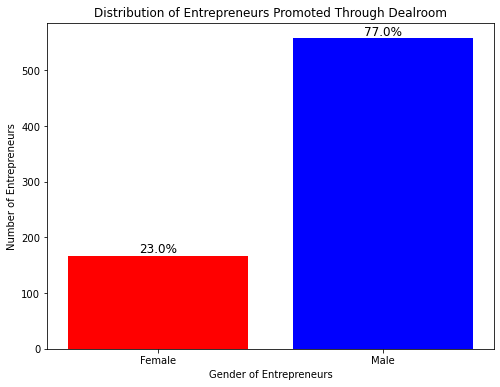

In [27]:
import csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dealroom = pd.read_csv('Dealroom_data_by_person.csv')

#Select gender column and get total
genders=dealroom['Gender']
total= len(dealroom)

#Count number of female entrepreneurs and get percentage
female_nr=dealroom.value_counts(subset=genders)['female']
fraction= ((female_nr)/(total))*100
f_p= round(fraction)


#Count number of male entrepreneurs and get percentage
male_nr=dealroom.value_counts(subset=genders)['male']
fraction= ((male_nr)/(total))*100
m_p= round(fraction)



#Plot gender distributions in Dealroom
females = dealroom[dealroom['Gender']=='female'].shape[0]
males = dealroom[dealroom['Gender']=='male'].shape[0]

plt.figure(figsize=(8, 6))
bar=plt.bar(['Female', 'Male'], [females, males], color=['red', 'blue'])
plt.xlabel('Gender of Entrepreneurs')
plt.ylabel('Number of Entrepreneurs')
plt.title('Distribution of Entrepreneurs Promoted Through Dealroom')
#Add percentages above bars
plt.bar_label(bar, labels=[f'{f_p:.1f}%', f'{m_p:.1f}%'], fontsize=12, label_type='edge')

plt.show()